# Step 0: Data Validation

This notebook validates the BraTS2020 preprocessed data before any model training.
Each section ends with a **PASS / FAIL / WARN** verdict. Do not proceed to Step 1 (baseline U-Net) until all sections pass.

**Checks covered:**
1. File integrity — all expected H5 slices exist and open
2. Shape & format — image and mask dimensions match expectations
3. Mask encoding — channel ordering and unique values are correct
4. Class imbalance — per-class voxel percentages across multiple volumes
5. Modality statistics — intensity ranges and distributions per MRI channel
6. Visual alignment — masks spatially match the MRI images
7. MRI-tumor correlation — T1ce bright ↔ ET, FLAIR bright ↔ edema
8. Generator output — batch shapes, one-hot encoding, normalization
9. Summary report

In [1]:
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import defaultdict

# ─────────────────────────────────────────────────────────
# CONFIGURATION — update these paths before running
# ─────────────────────────────────────────────────────────
DATA_DIR = "../preprocessed_data_cropped"   # path to preprocessed H5 slice files
NUM_VOLUMES = 369                    # total volumes in the dataset
NUM_SLICES = 128                     # slices per volume after preprocessing
EXPECTED_IMG_SHAPE = (192, 160, 4)  # (H, W, C) per slice — actual stored shape
EXPECTED_MASK_SHAPE_RAW = (192, 160, 3)  # (H, W, 3) per slice
VALIDATION_VOLUMES = [1, 5, 10, 20, 50, 100, 150, 200, 250, 300]  # volumes to inspect
MODALITY_NAMES = ["T1", "T1ce", "T2", "FLAIR"]
CLASS_NAMES = ["Background", "NCR/NET (Necrotic)", "ED (Edema)", "ET (GD-enhancing)"]

# Channel order in raw H5 mask — BraTS numeric label order: 1=NCR, 2=ED, 4=ET
# Confirmed by Section 7: ch2 is bright on T1ce (ET behaviour), ch1 bright on FLAIR (ED behaviour)
# After generator prepends background: [BG, NCR, ED, ET] = classes 0, 1, 2, 3
RAW_MASK_CHANNELS = ["NCR/NET (Necrotic)", "ED (Edema)", "ET (GD-enhancing)"]

# Spatial dims used for generator shape checks
SLICE_H, SLICE_W = EXPECTED_IMG_SHAPE[0], EXPECTED_IMG_SHAPE[1]

# Add parent dir to path so we can import the generator
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'data_processing'))

print(f"Data directory: {os.path.abspath(DATA_DIR)}")
print(f"Exists: {os.path.exists(DATA_DIR)}")
print()
print("Mask channel ordering (raw H5, before generator adds background):")
for i, name in enumerate(RAW_MASK_CHANNELS):
    print(f"  ch{i} → {name}")
print()
print("Mask channel ordering (generator output, used by model):")
for i, name in enumerate(["Background"] + RAW_MASK_CHANNELS):
    print(f"  ch{i} → {name}")

Data directory: /Users/dariamarc/Documents/brainTumorSurvival/preprocessed_data_cropped
Exists: True

Mask channel ordering (raw H5, before generator adds background):
  ch0 → NCR/NET (Necrotic)
  ch1 → ED (Edema)
  ch2 → ET (GD-enhancing)

Mask channel ordering (generator output, used by model):
  ch0 → Background
  ch1 → NCR/NET (Necrotic)
  ch2 → ED (Edema)
  ch3 → ET (GD-enhancing)


---
## Section 1: File Integrity
Check that every expected H5 slice file exists and can be opened.

In [2]:
print("=" * 60)
print("SECTION 1: FILE INTEGRITY")
print("=" * 60)

missing_files = []
corrupt_files = []
found_files = 0
expected_total = NUM_VOLUMES * NUM_SLICES

# Check a representative sample to save time: all slices for VALIDATION_VOLUMES,
# plus spot-check slice 0 and slice NUM_SLICES-1 for all volumes
print(f"Full check on {len(VALIDATION_VOLUMES)} volumes...")
for vol_id in VALIDATION_VOLUMES:
    for slice_idx in range(NUM_SLICES):
        fpath = os.path.join(DATA_DIR, f"volume_{vol_id}_slice_{slice_idx}.h5")
        if not os.path.exists(fpath):
            missing_files.append(fpath)
        else:
            try:
                with h5py.File(fpath, 'r') as f:
                    _ = f['image'].shape
                    _ = f['mask'].shape
                found_files += 1
            except Exception as e:
                corrupt_files.append((fpath, str(e)))

print(f"\nSpot-check: slice 0 and slice {NUM_SLICES-1} for all {NUM_VOLUMES} volumes...")
spot_missing = []
for vol_id in range(1, NUM_VOLUMES + 1):
    for slice_idx in [0, NUM_SLICES - 1]:
        fpath = os.path.join(DATA_DIR, f"volume_{vol_id}_slice_{slice_idx}.h5")
        if not os.path.exists(fpath):
            spot_missing.append(fpath)

print(f"\nResults:")
print(f"  Files checked (full): {len(VALIDATION_VOLUMES) * NUM_SLICES}")
print(f"  Files opened OK:      {found_files}")
print(f"  Missing (full check): {len(missing_files)}")
print(f"  Corrupt:              {len(corrupt_files)}")
print(f"  Missing (spot check across all volumes): {len(spot_missing)}")

if missing_files:
    print(f"\nFirst 5 missing: {missing_files[:5]}")
if corrupt_files:
    print(f"\nFirst 3 corrupt: {corrupt_files[:3]}")
if spot_missing:
    print(f"\nFirst 5 spot-missing: {spot_missing[:5]}")

s1_pass = (len(missing_files) == 0 and len(corrupt_files) == 0 and len(spot_missing) == 0)
print(f"\n>>> SECTION 1: {'PASS' if s1_pass else 'FAIL'}")

SECTION 1: FILE INTEGRITY
Full check on 10 volumes...

Spot-check: slice 0 and slice 127 for all 369 volumes...

Results:
  Files checked (full): 1280
  Files opened OK:      1280
  Missing (full check): 0
  Corrupt:              0
  Missing (spot check across all volumes): 0

>>> SECTION 1: PASS


---
## Section 2: Shape & Format Verification
Confirm that image and mask dimensions exactly match what the model expects.

In [3]:
print("=" * 60)
print("SECTION 2: SHAPE & FORMAT")
print("=" * 60)

shape_errors = []
sample_images = {}
sample_masks = {}

# Load one slice from each validation volume
for vol_id in VALIDATION_VOLUMES[:5]:
    slice_idx = NUM_SLICES // 2  # middle slice
    fpath = os.path.join(DATA_DIR, f"volume_{vol_id}_slice_{slice_idx}.h5")
    with h5py.File(fpath, 'r') as f:
        img = f['image'][:]
        msk = f['mask'][:]
    sample_images[vol_id] = img
    sample_masks[vol_id] = msk

    img_ok = (img.shape == EXPECTED_IMG_SHAPE)
    msk_ok = (msk.shape == EXPECTED_MASK_SHAPE_RAW)
    print(f"  Volume {vol_id:>3d} | image {img.shape} {'OK' if img_ok else 'MISMATCH'} "
          f"| mask {msk.shape} {'OK' if msk_ok else 'MISMATCH'} "
          f"| img dtype {img.dtype} | mask dtype {msk.dtype}")
    if not img_ok or not msk_ok:
        shape_errors.append(vol_id)

print(f"\nExpected image shape per slice: {EXPECTED_IMG_SHAPE}")
print(f"Expected mask shape per slice:  {EXPECTED_MASK_SHAPE_RAW}")
print(f"Shape errors: {len(shape_errors)} volumes")

s2_pass = len(shape_errors) == 0
print(f"\n>>> SECTION 2: {'PASS' if s2_pass else 'FAIL'}")

SECTION 2: SHAPE & FORMAT
  Volume   1 | image (192, 160, 4) OK | mask (192, 160, 3) OK | img dtype float64 | mask dtype uint8
  Volume   5 | image (192, 160, 4) OK | mask (192, 160, 3) OK | img dtype float64 | mask dtype uint8
  Volume  10 | image (192, 160, 4) OK | mask (192, 160, 3) OK | img dtype float64 | mask dtype uint8
  Volume  20 | image (192, 160, 4) OK | mask (192, 160, 3) OK | img dtype float64 | mask dtype uint8
  Volume  50 | image (192, 160, 4) OK | mask (192, 160, 3) OK | img dtype float64 | mask dtype uint8

Expected image shape per slice: (192, 160, 4)
Expected mask shape per slice:  (192, 160, 3)
Shape errors: 0 volumes

>>> SECTION 2: PASS


---
## Section 3: Mask Encoding Verification
Confirm what the mask channels contain and that they are binary (0/1). Check for overlap between channels (a voxel should belong to at most one class).

In [4]:
print("=" * 60)
print("SECTION 3: MASK ENCODING")
print("=" * 60)

# Load a full volume to analyse mask encoding
vol_id = VALIDATION_VOLUMES[2]  # use volume 10
mask_slices, img_slices = [], []
for s in range(NUM_SLICES):
    fpath = os.path.join(DATA_DIR, f"volume_{vol_id}_slice_{s}.h5")
    with h5py.File(fpath, 'r') as f:
        mask_slices.append(f['mask'][:])
        img_slices.append(f['image'][:])

vol_mask = np.stack(mask_slices, axis=0)  # (D, H, W, 3)
vol_img  = np.stack(img_slices,  axis=0)  # (D, H, W, 4)

print(f"Full volume mask shape: {vol_mask.shape}")
print(f"Full volume image shape: {vol_img.shape}")

print("\nMask unique values per channel:")
for ch, name in enumerate(RAW_MASK_CHANNELS):
    vals = np.unique(vol_mask[..., ch])
    print(f"  Ch {ch} ({name}): {vals}")

# Check mutual exclusivity: no voxel should be 1 in more than one channel
channel_sum = vol_mask.sum(axis=-1)  # (D, H, W) — should be 0 or 1
multi_label = (channel_sum > 1).sum()
print(f"\nMutual exclusivity: voxels assigned to >1 class = {multi_label}")
print(f"  (should be 0 — each voxel belongs to at most one class)")

# Value range check — masks should be binary
all_vals = np.unique(vol_mask)
is_binary = set(all_vals).issubset({0, 1})
print(f"\nAll mask values: {all_vals} — binary: {is_binary}")

s3_pass = (multi_label == 0) and is_binary
print(f"\n>>> SECTION 3: {'PASS' if s3_pass else 'FAIL' if multi_label > 0 else 'WARN — non-binary values'}")

SECTION 3: MASK ENCODING
Full volume mask shape: (128, 192, 160, 3)
Full volume image shape: (128, 192, 160, 4)

Mask unique values per channel:
  Ch 0 (NCR/NET (Necrotic)): [0 1]
  Ch 1 (ED (Edema)): [0 1]
  Ch 2 (ET (GD-enhancing)): [0 1]

Mutual exclusivity: voxels assigned to >1 class = 0
  (should be 0 — each voxel belongs to at most one class)

All mask values: [0 1] — binary: True

>>> SECTION 3: PASS


---
## Section 4: Class Imbalance Analysis
Compute the percentage of voxels per class across multiple volumes. Severe imbalance (background >> tumor) is expected in BraTS but the ratio matters for loss weighting.

SECTION 4: CLASS IMBALANCE
Class                       Mean %    Min %    Max %
----------------------------------------------------
Background                  97.37%   94.61%   99.44%
NCR/NET (Necrotic)           0.67%    0.00%    2.32%
ED (Edema)                   1.47%    0.19%    4.29%
ET (GD-enhancing)            0.48%    0.03%    1.18%


/var/folders/7r/n0f6xjmd5_b4xv5y6_x6mx9m0000gn/T/ipykernel_55181/971644809.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(tumor_data, labels=[n.split(" ")[0] for n in tumor_names],


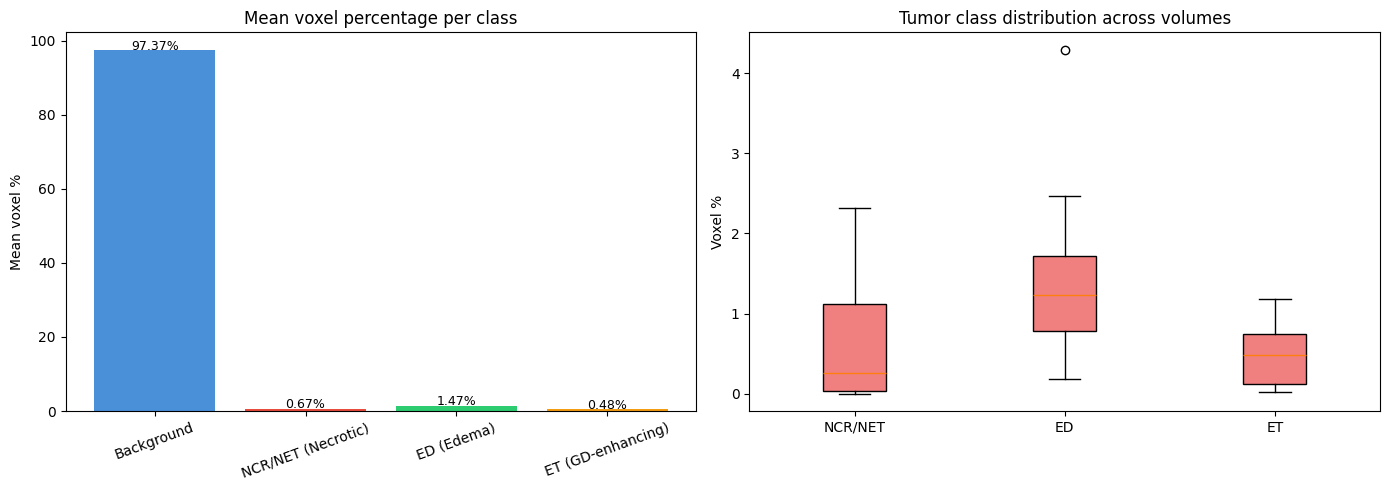


Smallest tumor class mean %: 0.484%
>>> SECTION 4: PASS


In [5]:
print("=" * 60)
print("SECTION 4: CLASS IMBALANCE")
print("=" * 60)

class_counts = defaultdict(list)  # {class_name: [pct_per_volume]}

for vol_id in VALIDATION_VOLUMES:
    mask_slices = []
    for s in range(NUM_SLICES):
        fpath = os.path.join(DATA_DIR, f"volume_{vol_id}_slice_{s}.h5")
        with h5py.File(fpath, 'r') as f:
            mask_slices.append(f['mask'][:])
    vmask = np.stack(mask_slices, axis=0)  # (D, H, W, 3)
    total = vmask.shape[0] * vmask.shape[1] * vmask.shape[2]

    tumor_voxels = vmask.sum(axis=-1)  # >0 means tumor
    bg_count = (tumor_voxels == 0).sum()
    class_counts["Background"].append(bg_count / total * 100)
    for ch, name in enumerate(RAW_MASK_CHANNELS):
        class_counts[name].append(vmask[..., ch].sum() / total * 100)

print(f"{'Class':<25} {'Mean %':>8} {'Min %':>8} {'Max %':>8}")
print("-" * 52)
all_names = ["Background"] + RAW_MASK_CHANNELS
for name in all_names:
    vals = class_counts[name]
    print(f"{name:<25} {np.mean(vals):>7.2f}% {np.min(vals):>7.2f}% {np.max(vals):>7.2f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: mean voxel % per class
means = [np.mean(class_counts[n]) for n in all_names]
colors = ["#4a90d9", "#e74c3c", "#2ecc71", "#f39c12"]
axes[0].bar(all_names, means, color=colors)
axes[0].set_ylabel("Mean voxel %")
axes[0].set_title("Mean voxel percentage per class")
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(means):
    axes[0].text(i, v + 0.1, f"{v:.2f}%", ha='center', fontsize=9)

# Box plot: per-volume variation for tumor classes only
tumor_names = RAW_MASK_CHANNELS
tumor_data = [class_counts[n] for n in tumor_names]
axes[1].boxplot(tumor_data, labels=[n.split(" ")[0] for n in tumor_names],
                patch_artist=True,
                boxprops=dict(facecolor='lightcoral'))
axes[1].set_ylabel("Voxel %")
axes[1].set_title("Tumor class distribution across volumes")

plt.tight_layout()
plt.show()

# Check: all tumor classes have at least some representation
min_tumor_pct = min(np.mean(class_counts[n]) for n in RAW_MASK_CHANNELS)
s4_pass = min_tumor_pct > 0.01  # at least 0.01% average
print(f"\nSmallest tumor class mean %: {min_tumor_pct:.3f}%")
print(f">>> SECTION 4: {'PASS' if s4_pass else 'WARN — a class has near-zero representation'}")

---
## Section 5: Modality Statistics
Check intensity ranges and distributions per MRI modality before and after normalization.

SECTION 5: MODALITY STATISTICS

Modality   Mean min   Mean max    % neg   % neg in brain Verdict
------------------------------------------------------------------------
T1            -0.60      61.24   64.36%           1.364%  OK (background z-score offset — generator handles)
T1ce          -0.64      53.05   63.93%           0.186%  OK (background z-score offset — generator handles)
T2            -0.63      67.86   63.93%           0.165%  OK (background z-score offset — generator handles)
FLAIR         -0.59      58.42   64.04%           0.481%  OK (background z-score offset — generator handles)

Note: ~64% of voxels being negative is expected when skull-stripped background
(originally 0) is shifted by per-brain z-score normalisation applied before saving.
The generator re-normalises each volume to [0, 1] before training, correcting this.


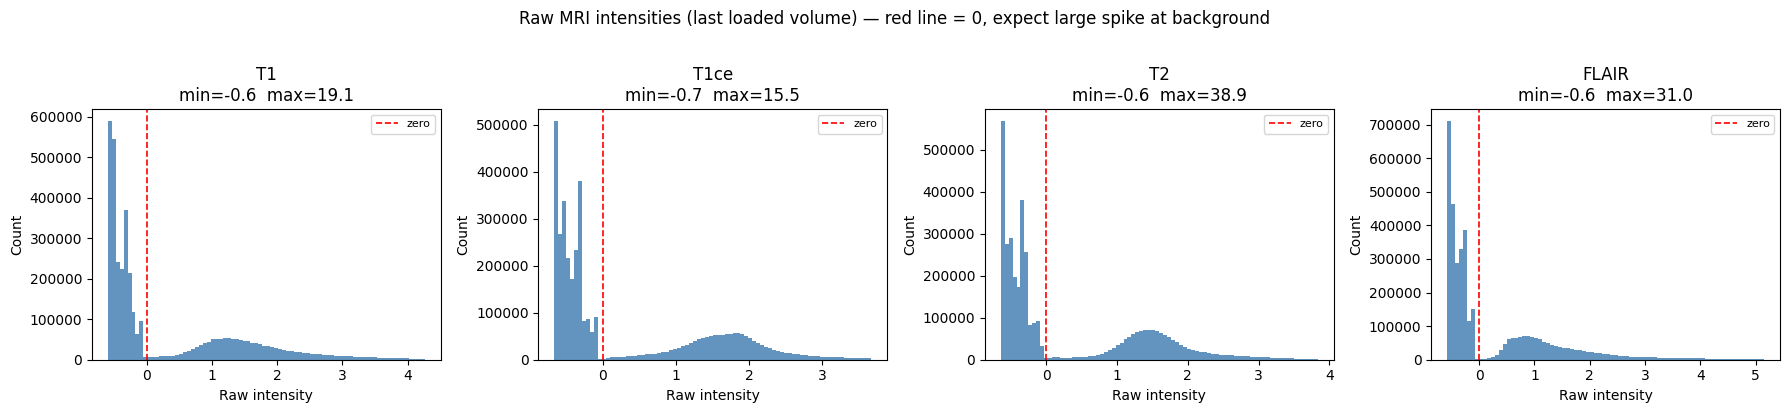


>>> SECTION 5: PASS


In [6]:
print("=" * 60)
print("SECTION 5: MODALITY STATISTICS")
print("=" * 60)

raw_stats = {m: {"min": [], "max": [], "mean": [], "std": [], "neg_pct": [], "neg_in_brain_pct": []} for m in MODALITY_NAMES}

for vol_id in VALIDATION_VOLUMES[:5]:
    img_slices, mask_slices = [], []
    for s in range(NUM_SLICES):
        fpath = os.path.join(DATA_DIR, f"volume_{vol_id}_slice_{s}.h5")
        with h5py.File(fpath, 'r') as f:
            img_slices.append(f['image'][:])
            mask_slices.append(f['mask'][:])
    vol_img  = np.stack(img_slices,  axis=0).astype(np.float32)
    vol_mask = np.stack(mask_slices, axis=0)

    brain_mask = (vol_img.max(axis=-1) > 0)  # non-background voxels

    for ch, name in enumerate(MODALITY_NAMES):
        ch_data = vol_img[..., ch]
        neg_in_brain = (ch_data < 0) & brain_mask
        raw_stats[name]["min"].append(float(ch_data.min()))
        raw_stats[name]["max"].append(float(ch_data.max()))
        raw_stats[name]["mean"].append(float(ch_data.mean()))
        raw_stats[name]["std"].append(float(ch_data.std()))
        raw_stats[name]["neg_pct"].append((ch_data < 0).sum() / ch_data.size * 100)
        raw_stats[name]["neg_in_brain_pct"].append(neg_in_brain.sum() / brain_mask.sum() * 100)

print(f"\n{'Modality':<8} {'Mean min':>10} {'Mean max':>10} {'% neg':>8} {'% neg in brain':>16} {'Verdict'}")
print("-" * 72)

modality_verdicts = {}
for name in MODALITY_NAMES:
    mean_min       = np.mean(raw_stats[name]["min"])
    mean_max       = np.mean(raw_stats[name]["max"])
    mean_neg_pct   = np.mean(raw_stats[name]["neg_pct"])
    mean_neg_brain = np.mean(raw_stats[name]["neg_in_brain_pct"])

    # Verdict rules:
    #   OK   — negatives only in background (< 5% of brain voxels) and small magnitude (min > -5)
    #          This is the normal BraTS pattern: background zeroed before z-score normalisation
    #          shifts it slightly negative. Generator min-max normalisation corrects this.
    #   WARN — negatives widespread in brain tissue (5–20% of brain voxels)
    #   FAIL — large-magnitude negatives throughout brain (min < -5 or > 20% of brain voxels)
    if mean_neg_brain < 5.0 and mean_min > -5.0:
        verdict = "OK (background z-score offset — generator handles)"
    elif mean_neg_brain < 20.0 and mean_min > -5.0:
        verdict = "WARN (negatives in brain, check normalisation)"
    else:
        verdict = "FAIL (significant negatives in brain tissue)"

    modality_verdicts[name] = verdict
    print(f"{name:<8} {mean_min:>10.2f} {mean_max:>10.2f} {mean_neg_pct:>7.2f}% {mean_neg_brain:>15.3f}%  {verdict}")

print(f"\nNote: ~64% of voxels being negative is expected when skull-stripped background")
print(f"(originally 0) is shifted by per-brain z-score normalisation applied before saving.")
print(f"The generator re-normalises each volume to [0, 1] before training, correcting this.")

# Intensity histograms
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ch, name in enumerate(MODALITY_NAMES):
    vals = vol_img[..., ch].flatten()
    p01, p99 = np.percentile(vals, 0.1), np.percentile(vals, 99)
    plot_vals = vals[(vals >= p01) & (vals <= p99)]
    color = 'salmon' if "FAIL" in modality_verdicts[name] or "WARN" in modality_verdicts[name] else 'steelblue'
    axes[ch].hist(plot_vals, bins=80, color=color, alpha=0.85)
    axes[ch].axvline(0, color='red', linewidth=1.2, linestyle='--', label='zero')
    axes[ch].set_title(f"{name}\nmin={vals.min():.1f}  max={vals.max():.1f}")
    axes[ch].set_xlabel("Raw intensity")
    axes[ch].set_ylabel("Count")
    axes[ch].legend(fontsize=8)
plt.suptitle("Raw MRI intensities (last loaded volume) — red line = 0, expect large spike at background", y=1.02)
plt.tight_layout()
plt.show()

any_fail = any("FAIL" in v for v in modality_verdicts.values())
any_warn = any("WARN" in v for v in modality_verdicts.values())
s5_pass = not any_fail
print(f"\n>>> SECTION 5: {'FAIL' if any_fail else 'WARN' if any_warn else 'PASS'}")

---
## Section 6: Visual Alignment Check
Show each modality alongside each mask channel for 3 different volumes. Verify that masks are spatially aligned with the images.

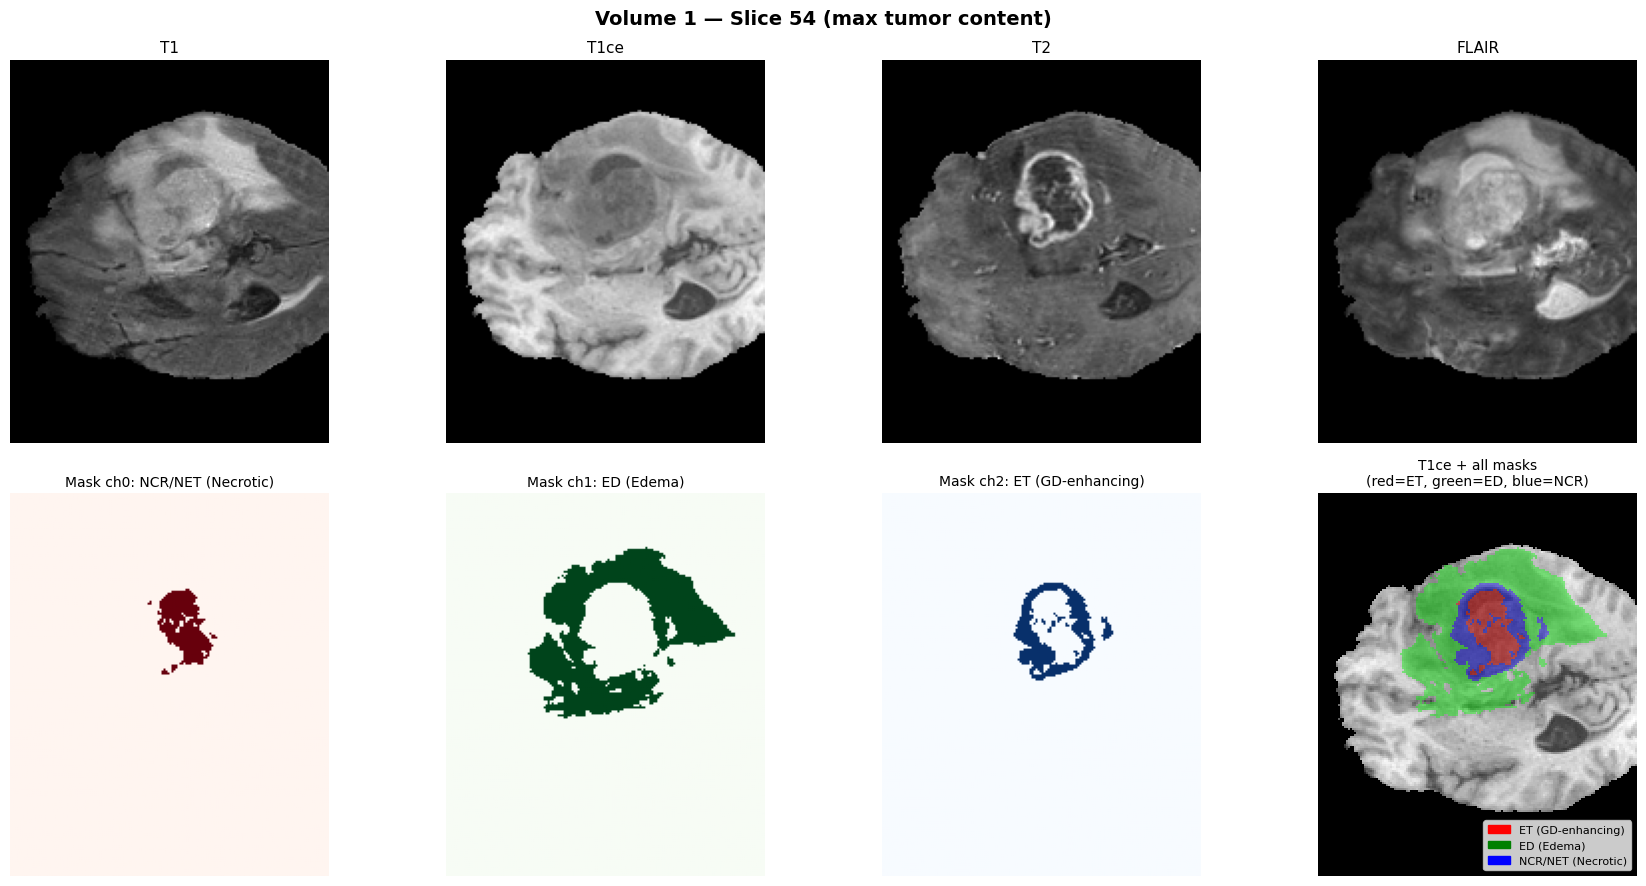

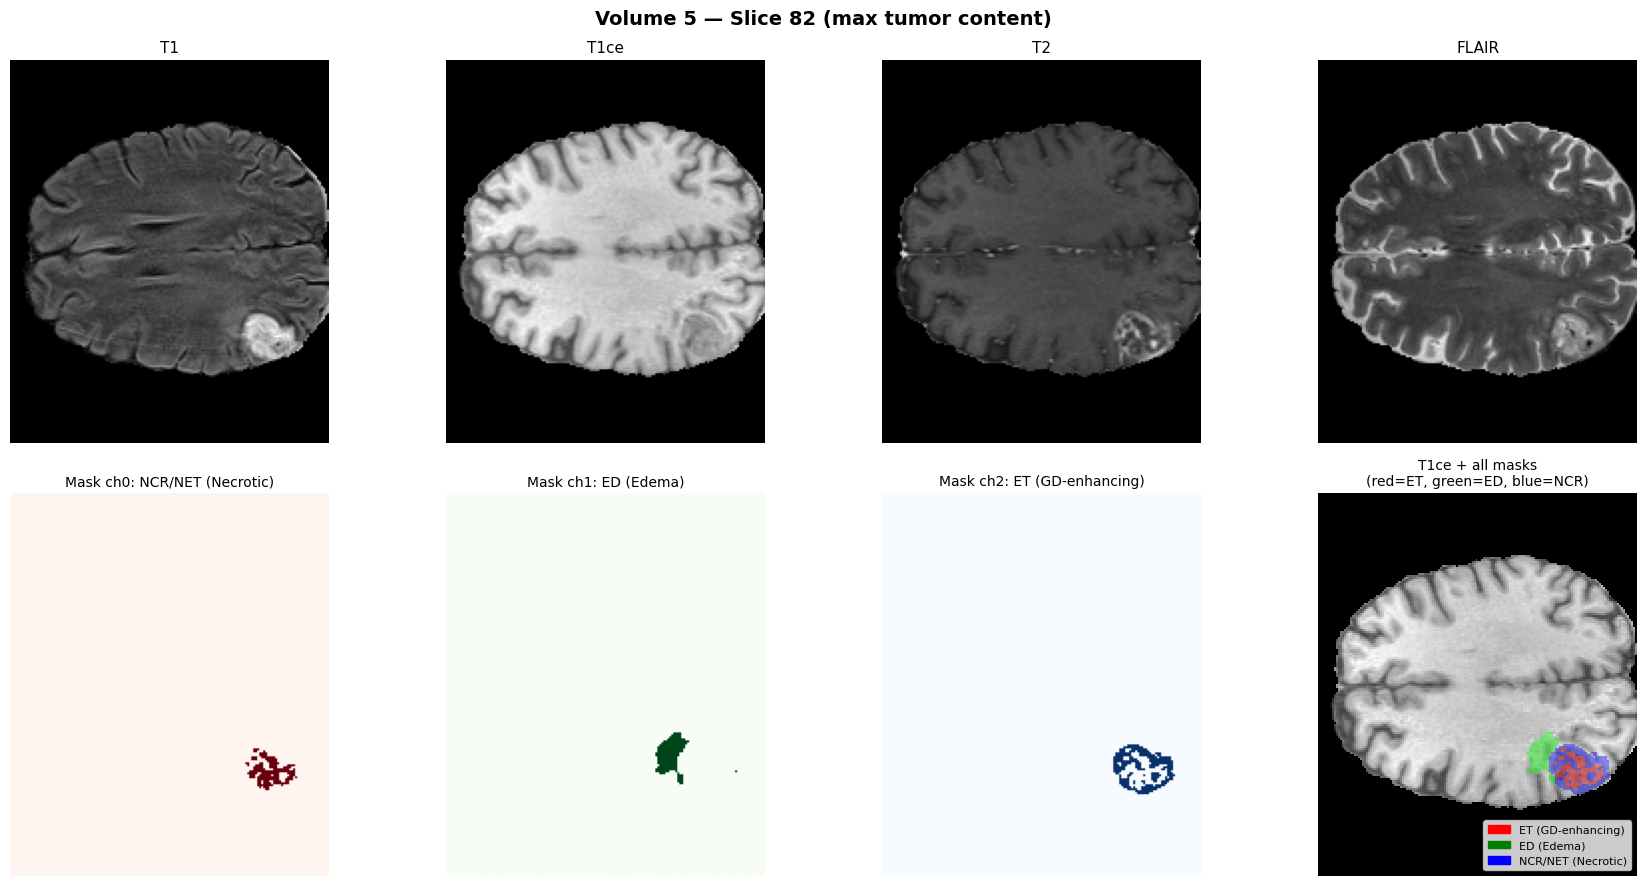

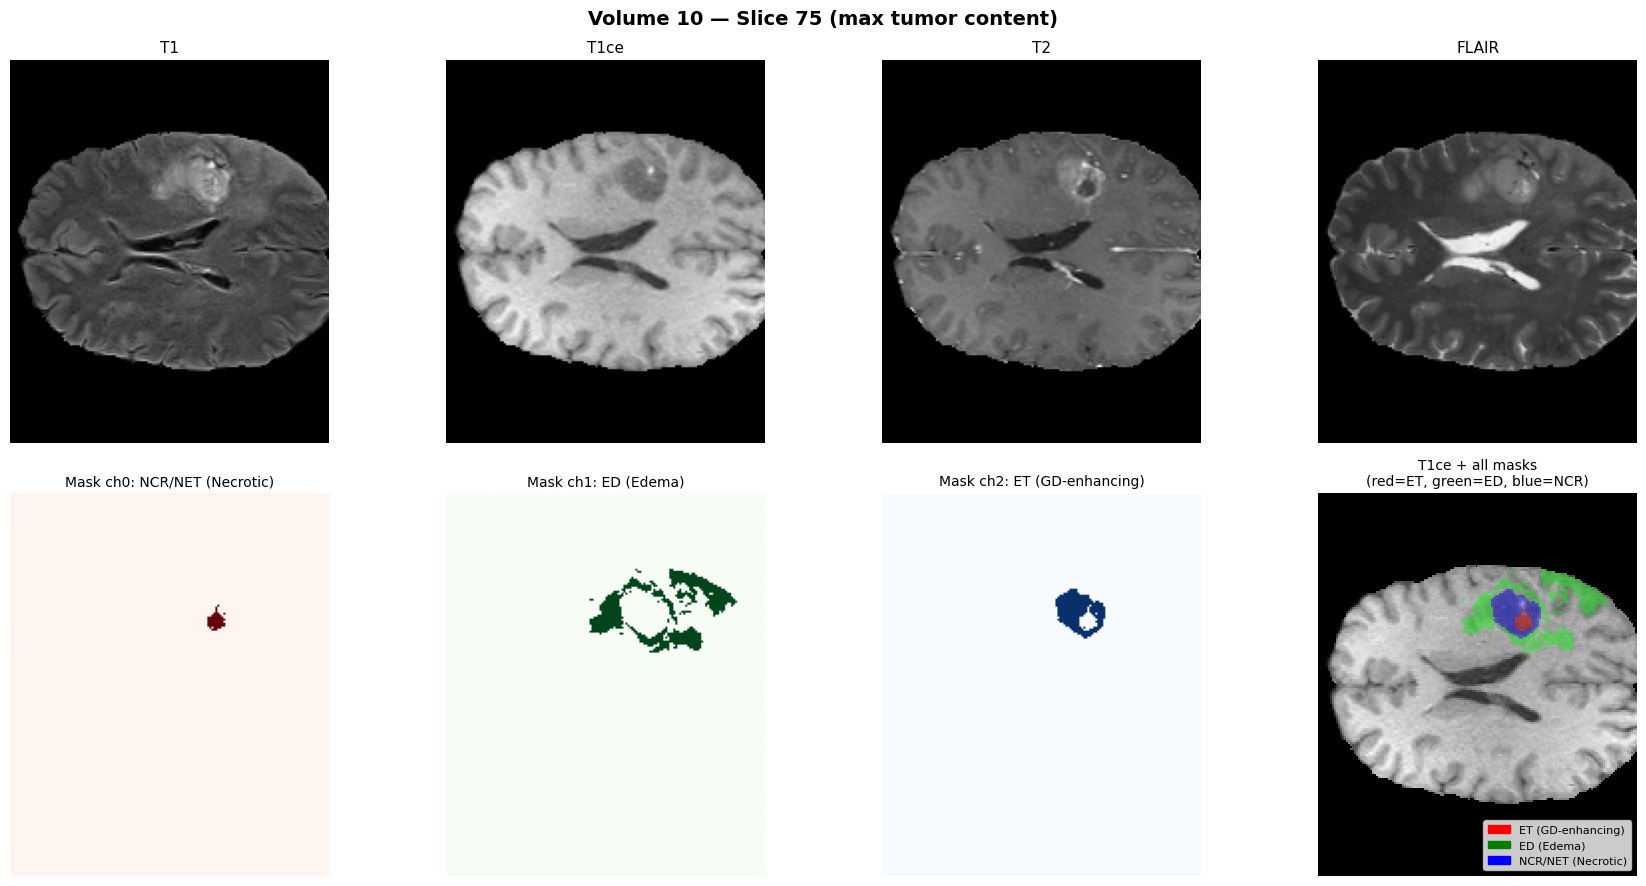


>>> SECTION 6: Visual check — manually confirm the overlay aligns with the tumor.
    PASS if masks are centred on the tumor region, not shifted or inverted.


In [7]:
def find_informative_slice(mask_vol):
    """Return the slice index with the most tumor voxels."""
    tumor_per_slice = mask_vol.sum(axis=(1, 2, 3))  # (D,)
    return int(np.argmax(tumor_per_slice))

def overlay_mask_on_image(ax, img_slice, mask_slice, alpha=0.4):
    """Display grayscale image with colored mask overlay."""
    ax.imshow(img_slice, cmap='gray', interpolation='none')
    # Build RGB overlay: ET=red, ED=green, NCR=blue
    overlay = np.zeros((*img_slice.shape, 4), dtype=np.float32)
    colors_rgba = [(1, 0, 0, alpha), (0, 1, 0, alpha), (0, 0, 1, alpha)]  # ET, ED, NCR
    for ch, rgba in enumerate(colors_rgba):
        where = mask_slice[..., ch] > 0
        overlay[where] = rgba
    ax.imshow(overlay, interpolation='none')

check_volumes = VALIDATION_VOLUMES[:3]

for vol_id in check_volumes:
    img_slices, mask_slices = [], []
    for s in range(NUM_SLICES):
        fpath = os.path.join(DATA_DIR, f"volume_{vol_id}_slice_{s}.h5")
        with h5py.File(fpath, 'r') as f:
            img_slices.append(f['image'][:])
            mask_slices.append(f['mask'][:])
    vol_img  = np.stack(img_slices,  axis=0)  # (D, H, W, 4)
    vol_mask = np.stack(mask_slices, axis=0)  # (D, H, W, 3)

    sl = find_informative_slice(vol_mask)
    img_s  = vol_img[sl]   # (H, W, 4)
    mask_s = vol_mask[sl]  # (H, W, 3)

    # Row 1: 4 modalities
    # Row 2: 3 mask channels + composite overlay on T1ce
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f"Volume {vol_id} — Slice {sl} (max tumor content)", fontsize=14, fontweight='bold')

    for ch, name in enumerate(MODALITY_NAMES):
        axes[0, ch].imshow(img_s[..., ch], cmap='gray')
        axes[0, ch].set_title(name, fontsize=11)
        axes[0, ch].axis('off')

    mask_colors = ['Reds', 'Greens', 'Blues']
    for ch, name in enumerate(RAW_MASK_CHANNELS):
        axes[1, ch].imshow(mask_s[..., ch], cmap=mask_colors[ch], vmin=0, vmax=1)
        axes[1, ch].set_title(f"Mask ch{ch}: {name}", fontsize=10)
        axes[1, ch].axis('off')

    # Composite overlay on T1ce (best modality for tumor visibility)
    overlay_mask_on_image(axes[1, 3], img_s[..., 1], mask_s)
    axes[1, 3].set_title("T1ce + all masks\n(red=ET, green=ED, blue=NCR)", fontsize=10)
    axes[1, 3].axis('off')

    patches = [
        mpatches.Patch(color='red',   label='ET (GD-enhancing)'),
        mpatches.Patch(color='green', label='ED (Edema)'),
        mpatches.Patch(color='blue',  label='NCR/NET (Necrotic)'),
    ]
    axes[1, 3].legend(handles=patches, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

print("\n>>> SECTION 6: Visual check — manually confirm the overlay aligns with the tumor.")
print("    PASS if masks are centred on the tumor region, not shifted or inverted.")

---
## Section 7: MRI-Tumor Correlation
Quantitatively verify that the expected MRI signal patterns are observed within each tumor class:
- **ET**: should be bright on T1ce (contrast-enhancing)
- **ED**: should be bright on FLAIR (peritumoral edema)
- **NCR**: should be dark on T1ce (necrotic/non-enhancing core)

SECTION 7: MRI-TUMOR CORRELATION

Channel mapping being tested:
  raw ch0 = NCR/NET  |  raw ch1 = ED  |  raw ch2 = ET

Expected MRI signal patterns:
  ET  (ch2): bright on T1ce — contrast-enhancing ring
  ED  (ch1): bright on FLAIR — peritumoral oedema
  NCR (ch0): bright on T2   — necrotic/mixed core (T1ce unreliable for NCR)

Check                            Inside    Outside    Ratio  Result
--------------------------------------------------------------------
ET on T1ce (ch2)                 0.0325     0.0136    2.392  bright inside  OK
ED on FLAIR (ch1)                0.0374     0.0131    2.846  bright inside  OK
NCR on T2 (ch0)                  0.0276     0.0121    2.281  bright inside  OK


/var/folders/7r/n0f6xjmd5_b4xv5y6_x6mx9m0000gn/T/ipykernel_55181/2902834898.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inside_vals, outside_vals], labels=["Inside mask", "Outside (BG)"],
/var/folders/7r/n0f6xjmd5_b4xv5y6_x6mx9m0000gn/T/ipykernel_55181/2902834898.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inside_vals, outside_vals], labels=["Inside mask", "Outside (BG)"],
/var/folders/7r/n0f6xjmd5_b4xv5y6_x6mx9m0000gn/T/ipykernel_55181/2902834898.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inside_vals, outside_vals], labels=["Inside mask", "Outside (BG)"]

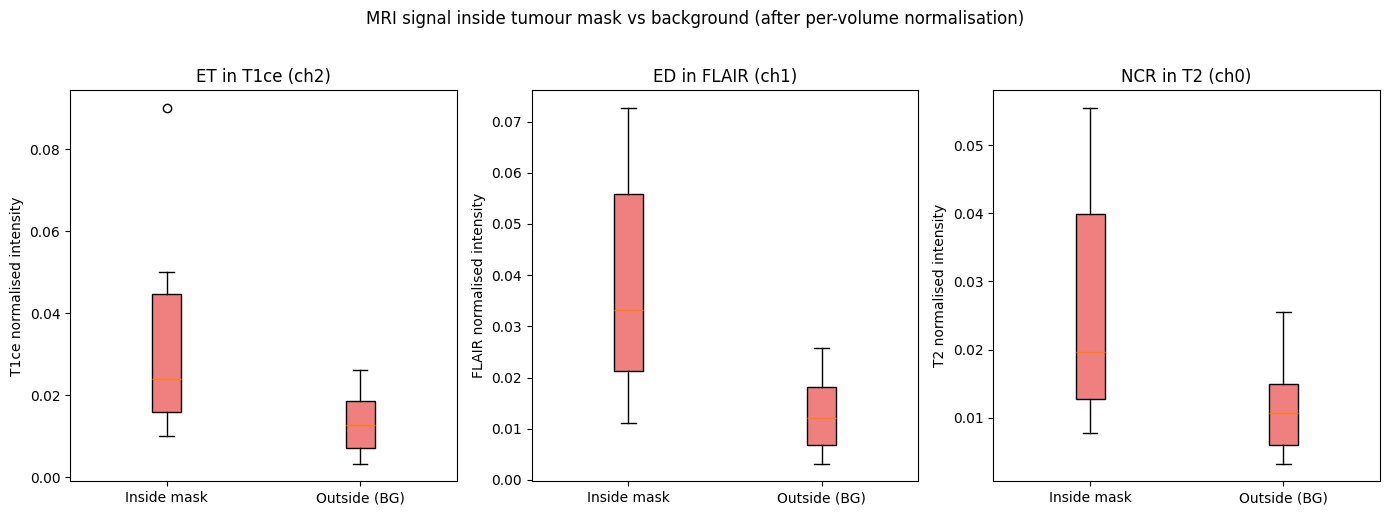


>>> SECTION 7: PASS


In [8]:
print("=" * 60)
print("SECTION 7: MRI-TUMOR CORRELATION")
print("=" * 60)
print()
print("Channel mapping being tested:")
print("  raw ch0 = NCR/NET  |  raw ch1 = ED  |  raw ch2 = ET")
print()
print("Expected MRI signal patterns:")
print("  ET  (ch2): bright on T1ce — contrast-enhancing ring")
print("  ED  (ch1): bright on FLAIR — peritumoral oedema")
print("  NCR (ch0): bright on T2   — necrotic/mixed core (T1ce unreliable for NCR)")

# Collect per-volume statistics
# raw mask: ch0=NCR, ch1=ED, ch2=ET
correlations = {
    "ET_T1ce_inside":   [], "ET_T1ce_outside":   [],
    "ED_FLAIR_inside":  [], "ED_FLAIR_outside":  [],
    "NCR_T2_inside":    [], "NCR_T2_outside":    [],
}

for vol_id in VALIDATION_VOLUMES:
    img_slices, mask_slices = [], []
    for s in range(NUM_SLICES):
        fpath = os.path.join(DATA_DIR, f"volume_{vol_id}_slice_{s}.h5")
        with h5py.File(fpath, 'r') as f:
            img_slices.append(f['image'][:].astype(np.float32))
            mask_slices.append(f['mask'][:])
    vol_img  = np.stack(img_slices,  axis=0)
    vol_mask = np.stack(mask_slices, axis=0)

    # Per-volume min-max normalisation (same as data generator)
    vmin, vmax = vol_img.min(), vol_img.max()
    if vmax - vmin > 1e-8:
        vol_img = (vol_img - vmin) / (vmax - vmin)

    T1ce  = vol_img[..., 1]   # channel 1
    T2    = vol_img[..., 2]   # channel 2
    FLAIR = vol_img[..., 3]   # channel 3

    # Correct channel order: ch0=NCR, ch1=ED, ch2=ET
    NCR = vol_mask[..., 0].astype(bool)
    ED  = vol_mask[..., 1].astype(bool)
    ET  = vol_mask[..., 2].astype(bool)
    BG  = ~(NCR | ED | ET)   # true background (no tumor)

    if ET.sum() > 50:
        correlations["ET_T1ce_inside"].append(T1ce[ET].mean())
        correlations["ET_T1ce_outside"].append(T1ce[BG].mean())
    if ED.sum() > 50:
        correlations["ED_FLAIR_inside"].append(FLAIR[ED].mean())
        correlations["ED_FLAIR_outside"].append(FLAIR[BG].mean())
    if NCR.sum() > 50:
        correlations["NCR_T2_inside"].append(T2[NCR].mean())
        correlations["NCR_T2_outside"].append(T2[BG].mean())

print(f"\n{'Check':<28} {'Inside':>10} {'Outside':>10} {'Ratio':>8}  {'Result'}")
print("-" * 68)

checks = [
    ("ET on T1ce (ch2)",   "ET_T1ce_inside",  "ET_T1ce_outside",  ">", "bright inside"),
    ("ED on FLAIR (ch1)",  "ED_FLAIR_inside", "ED_FLAIR_outside", ">", "bright inside"),
    ("NCR on T2 (ch0)",    "NCR_T2_inside",   "NCR_T2_outside",   ">", "bright inside"),
]

s7_results = []
for label, inside_key, outside_key, direction, expectation in checks:
    inside  = np.mean(correlations[inside_key])  if correlations[inside_key]  else float('nan')
    outside = np.mean(correlations[outside_key]) if correlations[outside_key] else float('nan')
    ratio   = inside / outside if outside > 0 else float('nan')
    ok = (inside > outside) if direction == ">" else (inside < outside)
    s7_results.append(ok)
    status = "OK" if ok else "FAIL"
    print(f"{label:<28} {inside:>10.4f} {outside:>10.4f} {ratio:>8.3f}  {expectation}  {status}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_info = [
    ("ET in T1ce (ch2)",  correlations["ET_T1ce_inside"],  correlations["ET_T1ce_outside"],  "T1ce normalised intensity"),
    ("ED in FLAIR (ch1)", correlations["ED_FLAIR_inside"], correlations["ED_FLAIR_outside"], "FLAIR normalised intensity"),
    ("NCR in T2 (ch0)",   correlations["NCR_T2_inside"],   correlations["NCR_T2_outside"],   "T2 normalised intensity"),
]
for ax, (title, inside_vals, outside_vals, ylabel) in zip(axes, plot_info):
    ax.boxplot([inside_vals, outside_vals], labels=["Inside mask", "Outside (BG)"],
               patch_artist=True, boxprops=dict(facecolor='lightcoral'))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
plt.suptitle("MRI signal inside tumour mask vs background (after per-volume normalisation)", y=1.02)
plt.tight_layout()
plt.show()

s7_pass = all(s7_results)
print(f"\n>>> SECTION 7: {'PASS' if s7_pass else 'FAIL — check channel ordering in masks'}")
if not s7_pass:
    print("     If ET or ED fail: the channel assignment (ch0/1/2) may still be wrong.")
    print("     If only NCR fails: NCR T2 signal can overlap with background — less reliable than ET/ED.")

---
## Section 8: Generator Output Validation
Run the actual MRIDataGenerator and verify the batch it produces: shapes, dtype, value range, one-hot encoding, and background channel logic.

In [9]:
print("=" * 60)
print("SECTION 8: GENERATOR OUTPUT (manual replication, no TF import)")
print("=" * 60)
print()
print("Replicating the MRIDataGenerator logic without importing TensorFlow.")
print("Loads one volume and verifies every step the generator performs.")

# ── Step 1: load raw slices ────────────────────────────────
VOL_ID = VALIDATION_VOLUMES[0]  # use first validation volume
img_slices, mask_slices = [], []

for s in range(NUM_SLICES):
    fpath = os.path.join(DATA_DIR, f"volume_{VOL_ID}_slice_{s}.h5")
    with h5py.File(fpath, 'r') as f:
        img_slices.append(f['image'][:])
        mask_slices.append(f['mask'][:])

raw_img  = np.stack(img_slices,  axis=0)  # (D, H, W, 4)
raw_mask = np.stack(mask_slices, axis=0)  # (D, H, W, 3)

print(f"\nStep 1 — Raw stacked shapes:")
print(f"  image: {raw_img.shape}  dtype: {raw_img.dtype}")
print(f"  mask:  {raw_mask.shape}  dtype: {raw_mask.dtype}")

# ── Step 2: normalisation (replicating generator) ─────────
raw_img = raw_img.astype(np.float32)
img_min, img_max = raw_img.min(), raw_img.max()
if img_max - img_min > 1e-8:
    norm_img = (raw_img - img_min) / (img_max - img_min)
else:
    norm_img = np.zeros_like(raw_img)

norm_ok = (norm_img.min() >= 0.0) and (norm_img.max() <= 1.0 + 1e-5)
print(f"\nStep 2 — After normalisation:")
print(f"  range: [{norm_img.min():.4f}, {norm_img.max():.4f}]  — in [0,1]: {norm_ok}")

# ── Step 3: cast mask to int32 ────────────────────────────
int_mask = raw_mask.astype(np.int32)
all_vals = np.unique(int_mask)
is_binary = set(all_vals).issubset({0, 1})
print(f"\nStep 3 — Mask cast to int32:")
print(f"  unique values: {all_vals}  — binary: {is_binary}")

# ── Step 4: add background channel ────────────────────────
tumor_sum = int_mask.sum(axis=-1, keepdims=True)       # (D, H, W, 1)
bg_channel = (tumor_sum == 0).astype(np.int32)          # 1 where no tumor
full_mask = np.concatenate([bg_channel, int_mask], axis=-1).astype(np.float32)  # (D, H, W, 4)

print(f"\nStep 4 — After adding background channel:")
print(f"  mask shape: {full_mask.shape}  (expected: ({NUM_SLICES}, {SLICE_H}, {SLICE_W}, 4))")

# ── Step 5: add batch dimension ───────────────────────────
images = norm_img[np.newaxis]    # (1, D, H, W, 4)
masks  = full_mask[np.newaxis]   # (1, D, H, W, 4)

EXPECTED_IMG_BATCH  = (1, NUM_SLICES, SLICE_H, SLICE_W, 4)
EXPECTED_MASK_BATCH = (1, NUM_SLICES, SLICE_H, SLICE_W, 4)

shapes_ok = (images.shape == EXPECTED_IMG_BATCH) and (masks.shape == EXPECTED_MASK_BATCH)
print(f"\nStep 5 — Batch shapes:")
print(f"  images: {images.shape}  expected: {EXPECTED_IMG_BATCH}  {'OK' if images.shape == EXPECTED_IMG_BATCH else 'MISMATCH'}")
print(f"  masks:  {masks.shape}  expected: {EXPECTED_MASK_BATCH}  {'OK' if masks.shape == EXPECTED_MASK_BATCH else 'MISMATCH'}")

# ── Step 6: one-hot check ─────────────────────────────────
class_sum = masks[0].sum(axis=-1)   # (D, H, W) — should be exactly 1 everywhere
unique_sums = np.unique(class_sum)
onehot_ok = set(unique_sums).issubset({0.0, 1.0})
print(f"\nStep 6 — One-hot check:")
print(f"  channel sums per voxel: {unique_sums}  — one-hot: {onehot_ok}")

# ── Step 7: background channel logic ─────────────────────
bg = masks[0, :, :, :, 0]
tumor_any = masks[0, :, :, :, 1:].sum(axis=-1) > 0
bg_correct = (np.all(bg[tumor_any] == 0) and np.all(bg[~tumor_any] == 1))
print(f"\nStep 7 — Background channel (ch0 = 1 where no tumour):")
print(f"  bg=0 inside tumour: {np.all(bg[tumor_any] == 0)}")
print(f"  bg=1 outside tumour: {np.all(bg[~tumor_any] == 1)}")
print(f"  correct: {bg_correct}")

# ── Step 8: class distribution ────────────────────────────
print(f"\nStep 8 — Class voxel % in volume {VOL_ID}:")
total_v = masks[0].shape[0] * masks[0].shape[1] * masks[0].shape[2]
gen_class_names = ["Background", "NCR/NET", "ED", "ET"]
for ch, name in enumerate(gen_class_names):
    pct = masks[0, :, :, :, ch].sum() / total_v * 100
    print(f"  ch{ch} {name}: {pct:.2f}%")

s8_pass = all([shapes_ok, norm_ok, onehot_ok, bg_correct])
print(f"\n>>> SECTION 8: {'PASS' if s8_pass else 'FAIL'}")

SECTION 8: GENERATOR OUTPUT (manual replication, no TF import)

Replicating the MRIDataGenerator logic without importing TensorFlow.
Loads one volume and verifies every step the generator performs.

Step 1 — Raw stacked shapes:
  image: (128, 192, 160, 4)  dtype: float64
  mask:  (128, 192, 160, 3)  dtype: uint8

Step 2 — After normalisation:
  range: [0.0000, 1.0000]  — in [0,1]: True

Step 3 — Mask cast to int32:
  unique values: [0 1]  — binary: True

Step 4 — After adding background channel:
  mask shape: (128, 192, 160, 4)  (expected: (128, 192, 160, 4))

Step 5 — Batch shapes:
  images: (1, 128, 192, 160, 4)  expected: (1, 128, 192, 160, 4)  OK
  masks:  (1, 128, 192, 160, 4)  expected: (1, 128, 192, 160, 4)  OK

Step 6 — One-hot check:
  channel sums per voxel: [1.]  — one-hot: True

Step 7 — Background channel (ch0 = 1 where no tumour):
  bg=0 inside tumour: True
  bg=1 outside tumour: True
  correct: True

Step 8 — Class voxel % in volume 1:
  ch0 Background: 94.61%
  ch1 NCR/

---
## Section 8b: Visualise a Generator Batch
Sanity-check the normalised image alongside the 4-channel mask (including background) that the model will actually receive.

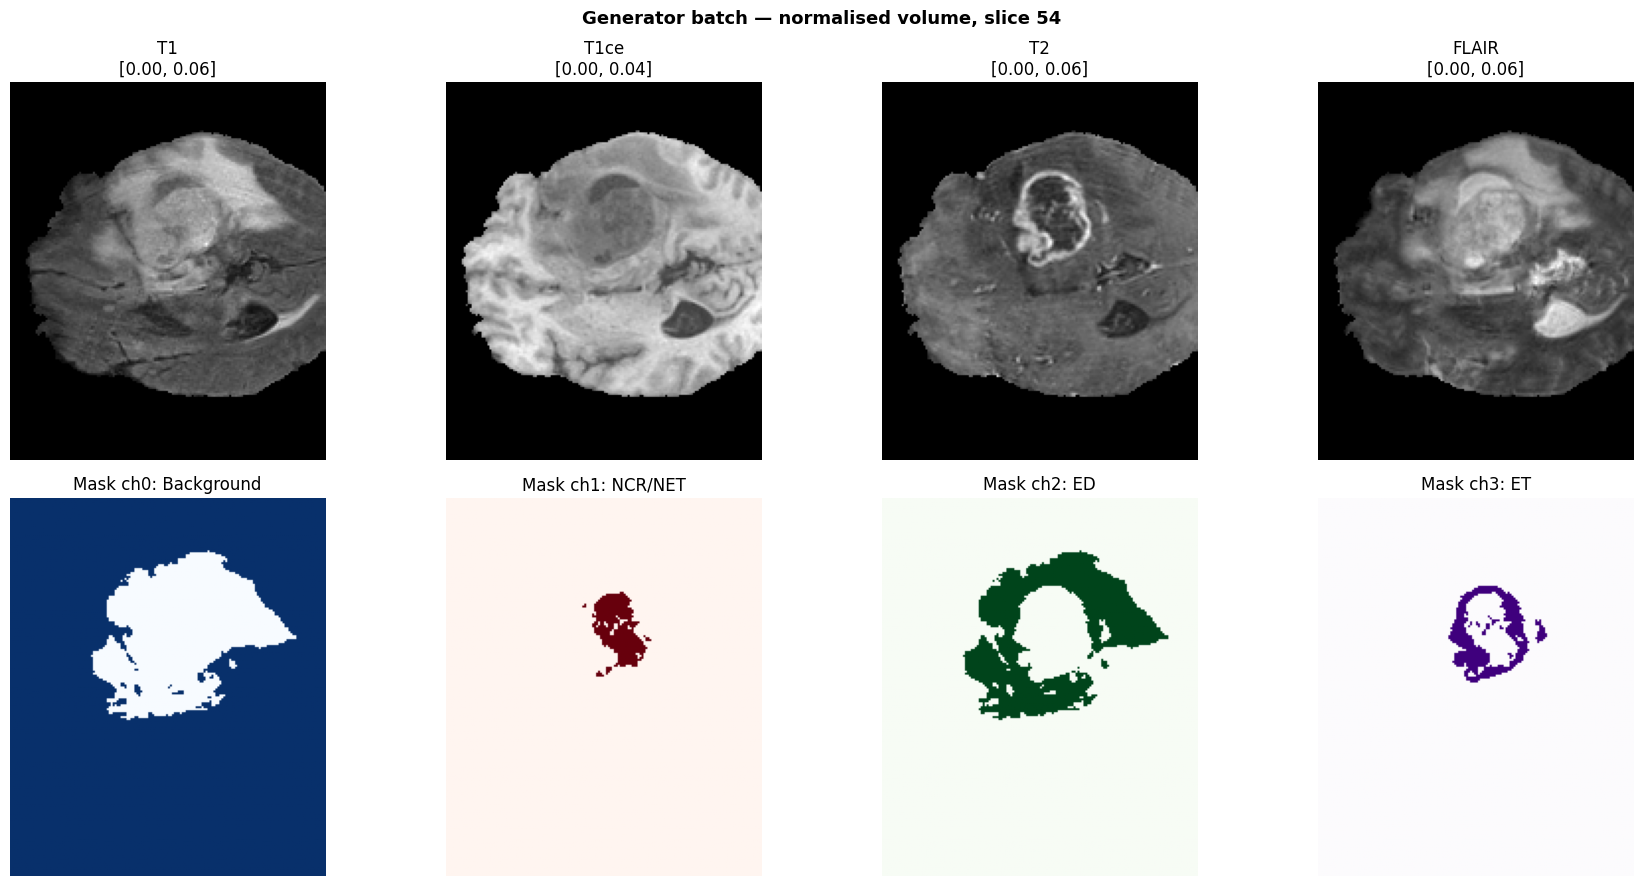

In [10]:
# Find most informative slice in this batch
tumor_per_sl = masks[0, :, :, :, 1:].sum(axis=(1, 2, 3))  # (D,) — sum over H, W, tumor classes
best_sl = int(np.argmax(tumor_per_sl))

img_s  = images[0, best_sl]  # (H, W, 4)
mask_s = masks[0, best_sl]   # (H, W, 4)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f"Generator batch — normalised volume, slice {best_sl}", fontsize=13, fontweight='bold')

# Row 1: modalities
for ch, name in enumerate(MODALITY_NAMES):
    axes[0, ch].imshow(img_s[..., ch], cmap='gray')
    axes[0, ch].set_title(f"{name}\n[{img_s[...,ch].min():.2f}, {img_s[...,ch].max():.2f}]")
    axes[0, ch].axis('off')

# Row 2: all 4 mask channels from generator output
gen_mask_cmaps = ['Blues', 'Reds', 'Greens', 'Purples']
for ch, (name, cmap) in enumerate(zip(gen_class_names, gen_mask_cmaps)):
    axes[1, ch].imshow(mask_s[..., ch], cmap=cmap, vmin=0, vmax=1)
    axes[1, ch].set_title(f"Mask ch{ch}: {name}")
    axes[1, ch].axis('off')

plt.tight_layout()
plt.show()

---
## Section 9: Summary Report

In [11]:
print("=" * 60)
print("STEP 0 VALIDATION SUMMARY")
print("=" * 60)

results = [
    ("1. File integrity",        s1_pass),
    ("2. Shape & format",        s2_pass),
    ("3. Mask encoding",         s3_pass),
    ("4. Class imbalance",       s4_pass),
    ("5. Modality statistics",   s5_pass),
    ("6. Visual alignment",      None),   # manual check
    ("7. MRI-tumor correlation", s7_pass),
    ("8. Generator output",      s8_pass),
]

all_auto_pass = all(v for _, v in results if v is not None)

for name, status in results:
    if status is None:
        verdict = "MANUAL CHECK REQUIRED"
    elif status:
        verdict = "PASS"
    else:
        verdict = "FAIL"
    print(f"  {name:<30} {verdict}")

print()
if all_auto_pass:
    print("All automated checks PASSED.")
    print("Complete the visual check in Section 6, then proceed to Step 1: plain U-Net baseline.")
else:
    failing = [name for name, v in results if v is False]
    print(f"FAILED sections: {failing}")
    print("Fix these issues before proceeding. Do NOT start Step 1 with a broken data pipeline.")

print()
print("Key numbers for Step 1 (record these):")
print(f"  Mean background %:  {np.mean(class_counts['Background']):.1f}%")
for name in RAW_MASK_CHANNELS:
    print(f"  Mean {name.split()[0]} %:          {np.mean(class_counts[name]):.2f}%")
print(f"  Generator batch shape: images {images.shape}, masks {masks.shape}")

STEP 0 VALIDATION SUMMARY
  1. File integrity              PASS
  2. Shape & format              PASS
  3. Mask encoding               PASS
  4. Class imbalance             PASS
  5. Modality statistics         PASS
  6. Visual alignment            MANUAL CHECK REQUIRED
  7. MRI-tumor correlation       PASS
  8. Generator output            PASS

All automated checks PASSED.
Complete the visual check in Section 6, then proceed to Step 1: plain U-Net baseline.

Key numbers for Step 1 (record these):
  Mean background %:  97.4%
  Mean NCR/NET %:          0.67%
  Mean ED %:          1.47%
  Mean ET %:          0.48%
  Generator batch shape: images (1, 128, 192, 160, 4), masks (1, 128, 192, 160, 4)
